In [1]:
import sys
import subprocess

def install_if_missing(package, import_name=None):
    import_name = import_name or package
    try:
        __import__(import_name)
    except ImportError:
        print(f"Встановлення {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "--quiet"])

# Встановлення необхідних пакетів
packages = {
    'numpy': 'numpy',
    'scipy': 'scipy',
    'plotly': 'plotly',
    'ipywidgets': 'ipywidgets'
}

for pkg, import_name in packages.items():
    install_if_missing(pkg, import_name)

# Імпорт бібліотек
import numpy as np
from scipy import signal
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from ipywidgets import FloatSlider, Checkbox, Button, VBox, HBox, Output, HTML
from IPython.display import display, clear_output

print("✓ Всі бібліотеки імпортовані успішно!")

✓ Всі бібліотеки імпортовані успішно!


In [2]:
class HarmonicGenerator:
    """Генератор гармонічних сигналів з шумом"""
    
    def __init__(self):
        self.t = np.linspace(0, 10, 1000)
        self.reset_params()

    def reset_params(self):
        """Скидання параметрів до початкових значень"""
        self.amplitude = 1.0
        self.frequency = 1.0
        self.phase = 0.0
        self.noise_mean = 0.0
        self.noise_std = 0.1
        self.generate_noise()

    def generate_noise(self):
        """Генерація нового шуму"""
        self.noise = np.random.normal(self.noise_mean, self.noise_std, len(self.t))

    def harmonic(self, amplitude, frequency, phase):
        """Генерація чистої гармоніки"""
        return amplitude * np.sin(2 * np.pi * frequency * self.t + phase)

    def apply_filter(self, signal_data, cutoff_freq):
        """Застосування фільтра Баттерворта"""
        nyquist = 0.5 * (len(self.t) / (self.t[-1] - self.t[0]))
        normal_cutoff = min(cutoff_freq / nyquist, 0.99)
        b, a = signal.butter(4, normal_cutoff, btype='low')
        return signal.filtfilt(b, a, signal_data)

print("✓ HarmonicGenerator готовий!")

✓ HarmonicGenerator готовий!


In [3]:
class InteractiveHarmonic:
    """Інтерактивна візуалізація гармоніки з шумом та фільтрацією"""
    
    def __init__(self):
        self.gen = HarmonicGenerator()
        self.last_noise_params = (0.0, 0.1)
        self.output = Output()
        self.create_widgets()

    def create_widgets(self):
        """Створення інтерактивних елементів"""
        style = {'description_width': '110px'}
        layout_s = {'width': '350px'}

        # Слайдери для параметрів гармоніки
        self.amp_slider = FloatSlider(
            value=1.0, min=0.1, max=2.0, step=0.1,
            description='Амплітуда:', style=style, layout=layout_s
        )
        self.freq_slider = FloatSlider(
            value=1.0, min=0.1, max=5.0, step=0.1,
            description='Частота:', style=style, layout=layout_s
        )
        self.phase_slider = FloatSlider(
            value=0.0, min=0.0, max=6.28, step=0.1,
            description='Фаза:', style=style, layout=layout_s
        )
        
        # Слайдери для параметрів шуму
        self.noise_mean_slider = FloatSlider(
            value=0.0, min=-0.5, max=0.5, step=0.05,
            description='Середнє шуму:', style=style, layout=layout_s
        )
        self.noise_std_slider = FloatSlider(
            value=0.1, min=0.0, max=0.5, step=0.01,
            description='Дисперсія шуму:', style=style, layout=layout_s
        )
        
        # Слайдер для фільтра
        self.cutoff_slider = FloatSlider(
            value=5.0, min=1.0, max=20.0, step=0.5,
            description='Частота зрізу:', style=style, layout=layout_s
        )

        # Чекбокси
        self.show_noise_check = Checkbox(value=True, description='Показати шум')
        self.show_filtered_check = Checkbox(value=True, description='Показати фільтр')
        
        # Кнопка Reset
        self.reset_button = Button(description='Reset', button_style='warning')
        self.reset_button.on_click(self.reset)

        # Прив'язка обробників подій
        for slider in [self.amp_slider, self.freq_slider, self.phase_slider]:
            slider.observe(self.on_harmonic_change, names='value')
        
        for slider in [self.noise_mean_slider, self.noise_std_slider]:
            slider.observe(self.on_noise_change, names='value')
        
        for w in [self.cutoff_slider, self.show_noise_check, self.show_filtered_check]:
            w.observe(self.update_plot, names='value')

    def on_harmonic_change(self, change):
        """Обробка зміни параметрів гармоніки"""
        self.gen.amplitude = self.amp_slider.value
        self.gen.frequency = self.freq_slider.value
        self.gen.phase = self.phase_slider.value
        self.update_plot(change)

    def on_noise_change(self, change):
        """Обробка зміни параметрів шуму (генерація нового шуму)"""
        current = (round(self.noise_mean_slider.value, 5), 
                  round(self.noise_std_slider.value, 5))
        
        if current != self.last_noise_params:
            self.gen.noise_mean = current[0]
            self.gen.noise_std = current[1]
            self.gen.generate_noise()
            self.last_noise_params = current
        
        self.update_plot(change)

    def reset(self, b):
        """Скидання всіх параметрів до початкових"""
        # Тимчасово відключаємо observers
        for slider in [self.amp_slider, self.freq_slider, self.phase_slider]:
            slider.unobserve(self.on_harmonic_change, names='value')
        for slider in [self.noise_mean_slider, self.noise_std_slider]:
            slider.unobserve(self.on_noise_change, names='value')

        # Скидання генератора
        self.gen.reset_params()
        
        # Скидання віджетів
        self.amp_slider.value = 1.0
        self.freq_slider.value = 1.0
        self.phase_slider.value = 0.0
        self.noise_mean_slider.value = 0.0
        self.noise_std_slider.value = 0.1
        self.cutoff_slider.value = 5.0
        self.show_noise_check.value = True
        self.show_filtered_check.value = True
        self.last_noise_params = (0.0, 0.1)

        # Повторно підключаємо observers
        for slider in [self.amp_slider, self.freq_slider, self.phase_slider]:
            slider.observe(self.on_harmonic_change, names='value')
        for slider in [self.noise_mean_slider, self.noise_std_slider]:
            slider.observe(self.on_noise_change, names='value')

        self.update_plot(None)

    def update_plot(self, change):
        """Оновлення графіків"""
        # Генерація сигналів
        clean = self.gen.harmonic(self.gen.amplitude, self.gen.frequency, self.gen.phase)
        noisy = clean + self.gen.noise

        # Створення графіка з двома підграфіками
        fig = make_subplots(
            rows=2, cols=1,
            subplot_titles=('Оригінальний сигнал', 'Відфільтрований сигнал'),
            vertical_spacing=0.12
        )

        # --- Верхній графік: оригінальний сигнал ---
        fig.add_trace(go.Scatter(
            x=self.gen.t, y=clean,
            name='Чиста гармоніка',
            line=dict(color='royalblue', width=2)
        ), row=1, col=1)

        if self.show_noise_check.value:
            fig.add_trace(go.Scatter(
                x=self.gen.t, y=noisy,
                name='Зашумлений сигнал',
                line=dict(color='orange', width=1),
                opacity=0.7
            ), row=1, col=1)

        # --- Нижній графік: відфільтрований сигнал ---
        if self.show_filtered_check.value:
            source = noisy if self.show_noise_check.value else clean
            filtered = self.gen.apply_filter(source, self.cutoff_slider.value)

            fig.add_trace(go.Scatter(
                x=self.gen.t, y=filtered,
                name='Відфільтрований',
                line=dict(color='green', width=2)
            ), row=2, col=1)

            fig.add_trace(go.Scatter(
                x=self.gen.t, y=clean,
                name='Чиста (еталон)',
                line=dict(color='royalblue', width=1, dash='dash'),
                opacity=0.5
            ), row=2, col=1)

        # Налаштування макета
        fig.update_layout(
            height=600,
            template='plotly_white',
            legend=dict(orientation='h', y=-0.12),
            margin=dict(t=60, b=80)
        )
        fig.update_xaxes(title_text='Час (с)')
        fig.update_yaxes(title_text='Амплітуда')

        # Відображення графіка (ВИПРАВЛЕНО!)
        with self.output:
            clear_output(wait=True)
            display(fig)  # Використовуємо display замість fig.show()

    def display(self):
        """Відображення інтерфейсу"""
        title = HTML("<h3> Інтерактивна візуалізація гармоніки</h3>")

        instructions = HTML("""
        <div style='background:#f0f4ff; padding:10px; border-radius:8px; 
                    margin-bottom:10px; font-size:13px'>
        <b>📖 Інструкція:</b><br>
        • <b>Амплітуда / Частота / Фаза</b> — параметри гармоніки (шум не змінюється)<br>
        • <b>Середнє / Дисперсія шуму</b> — параметри шуму (генерується новий шум)<br>
        • <b>Частота зрізу</b> — частота фільтра (менше = більше згладжування)<br>
        • <b>Показати шум</b> — показати/сховати шум на графіку<br>
        • <b>Показати фільтр</b> — показати/сховати відфільтрований сигнал<br>
        • <b> Reset</b> — повернути всі параметри до початкових<br><br>
        <b> Важливо:</b> Зміна параметрів гармоніки НЕ змінює шум. 
        Шум генерується заново тільки при зміні його параметрів.
        </div>
        """)

        # Організація віджетів у колонки
        col1 = VBox([
            HTML("<b> Параметри гармоніки</b>"),
            self.amp_slider,
            self.freq_slider,
            self.phase_slider
        ])
        
        col2 = VBox([
            HTML("<b> Параметри шуму</b>"),
            self.noise_mean_slider,
            self.noise_std_slider
        ])
        
        col3 = VBox([
            HTML("<b>🔧 Фільтр та відображення</b>"),
            self.cutoff_slider,
            self.show_noise_check,
            self.show_filtered_check,
            self.reset_button
        ])

        controls = HBox([col1, col2, col3], 
                       layout={'justify_content': 'space-around'})
        
        display(VBox([title, instructions, controls, self.output]))
        self.update_plot(None)

print("✓ InteractiveHarmonic готовий!")

✓ InteractiveHarmonic готовий!


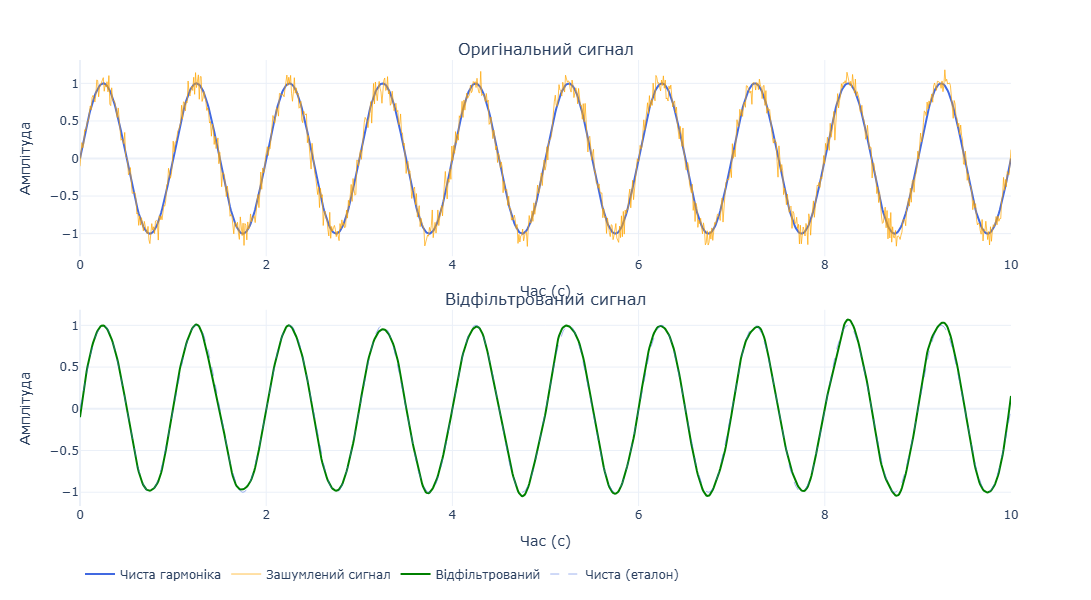

In [4]:
# Створення та запуск інтерактивного додатку
app = InteractiveHarmonic()
app.display()